In [1]:
import os
import cv2
import math
import torch
import random
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import swin3d_t, Swin3D_T_Weights

# =========================
# BASIC SETUP
# =========================
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data"
VIDEO_ROOT = os.path.join(ROOT, "GenderClips")
CSV_PATH = os.path.join(ROOT, "Labels", "AllLabels.csv")
SAVE_PATH = "BEST_DAISEE_BINARY_FINAL.pth"

SEED = 42
BATCH = 2
ACCUM = 4
EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 2
NUM_FRAMES = 16
IMG = 160
THRESHOLDS = np.arange(0.30, 0.81, 0.05)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


# =========================
# PATH HELPERS
# =========================
def find_video_path(clip_id: str):
    clip_id = str(clip_id).strip()

    male = os.path.join(VIDEO_ROOT, "Male", clip_id + ".avi")
    female = os.path.join(VIDEO_ROOT, "Female", clip_id + ".avi")

    if os.path.exists(male):
        return male
    if os.path.exists(female):
        return female
    return None


# =========================
# DATA PREP
# =========================
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df["ClipID"] = df["ClipID"].astype(str).str.strip()

# Binary label
# 집중 = Engagement >= 2
# 비집중 = Engagement 0 또는 1
df["label"] = (df["Engagement"] >= 2).astype(int)

# 실제 파일 경로 매핑
df["video_path"] = df["ClipID"].apply(find_video_path)

total_rows = len(df)
missing_rows = df["video_path"].isna().sum()

print(f"전체 라벨 수: {total_rows}")
print(f"영상 못 찾은 수: {missing_rows}")

# 없는 영상 제거
df = df[df["video_path"].notna()].reset_index(drop=True)

print("실제 학습 가능 수:", len(df))
print("라벨 분포:")
print(df["label"].value_counts())

# stratify split
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

print("train label 분포:")
print(train_df["label"].value_counts())
print("val label 분포:")
print(val_df["label"].value_counts())


# =========================
# DATASET
# =========================
class DaiseeDataset(Dataset):
    def __init__(self, df: pd.DataFrame, train: bool = True):
        self.df = df.reset_index(drop=True)
        self.train = train

    def __len__(self):
        return len(self.df)

    def _sample_frame_indices(self, total_frames: int):
        if total_frames <= 0:
            return [0] * NUM_FRAMES

        if total_frames < NUM_FRAMES:
            indices = list(range(total_frames))
            while len(indices) < NUM_FRAMES:
                indices.append(indices[-1])
            return indices

        if self.train:
            # train: 구간별 랜덤 샘플링
            segments = np.linspace(0, total_frames, NUM_FRAMES + 1, dtype=int)
            indices = []
            for i in range(NUM_FRAMES):
                start = segments[i]
                end = max(segments[i + 1] - 1, start)
                idx = random.randint(start, end)
                indices.append(idx)
            return indices

        # val: 균등 샘플링
        return np.linspace(0, total_frames - 1, NUM_FRAMES, dtype=int).tolist()

    def load_video(self, path: str):
        if path is None or not os.path.exists(path):
            return torch.zeros(3, NUM_FRAMES, IMG, IMG, dtype=torch.float32)

        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            return torch.zeros(3, NUM_FRAMES, IMG, IMG, dtype=torch.float32)

        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = self._sample_frame_indices(total)

        frames = []
        for frame_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()

            if not ret or frame is None:
                if len(frames) > 0:
                    frames.append(frames[-1].copy())
                else:
                    frames.append(np.zeros((IMG, IMG, 3), dtype=np.uint8))
                continue

            frame = cv2.resize(frame, (IMG, IMG), interpolation=cv2.INTER_AREA)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if self.train and random.random() < 0.5:
                frame = cv2.flip(frame, 1)

            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            return torch.zeros(3, NUM_FRAMES, IMG, IMG, dtype=torch.float32)

        while len(frames) < NUM_FRAMES:
            frames.append(frames[-1].copy())

        frames = np.stack(frames[:NUM_FRAMES]).astype(np.float32) / 255.0
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).contiguous()

        return frames

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        video = self.load_video(row["video_path"])
        label = int(row["label"])
        return video, label


train_dataset = DaiseeDataset(train_df, train=True)
val_dataset = DaiseeDataset(val_df, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)


# =========================
# CLASS WEIGHT
# =========================
train_labels = train_df["label"].values
class_counts = np.bincount(train_labels, minlength=2)
class_weights = len(train_labels) / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("class_counts:", class_counts)
print("class_weights:", class_weights)


# =========================
# MODEL
# =========================
model = swin3d_t(weights=Swin3D_T_Weights.DEFAULT)

in_features = model.head.in_features
model.head = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.amp.GradScaler("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# VALIDATION THRESHOLD SEARCH
# =========================
def evaluate_with_best_threshold(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for video, label in loader:
            video = video.to(DEVICE, non_blocking=True)
            video = video.contiguous(memory_format=torch.channels_last_3d)

            with torch.amp.autocast("cuda" if torch.cuda.is_available() else "cpu"):
                logits = model(video)
                probs = torch.softmax(logits, dim=1)[:, 1]

            all_probs.extend(probs.detach().cpu().numpy().tolist())
            all_labels.extend(label.numpy().tolist())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    best_threshold = 0.5
    best_f1 = -1
    best_acc = 0
    best_precision = 0
    best_recall = 0

    for th in THRESHOLDS:
        preds = (all_probs >= th).astype(int)

        f1 = f1_score(all_labels, preds, zero_division=0)
        acc = accuracy_score(all_labels, preds)
        precision = precision_score(all_labels, preds, zero_division=0)
        recall = recall_score(all_labels, preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = th
            best_acc = acc
            best_precision = precision
            best_recall = recall

    return {
        "f1": best_f1,
        "acc": best_acc,
        "precision": best_precision,
        "recall": best_recall,
        "threshold": best_threshold,
    }


# =========================
# TRAIN
# =========================
best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, (video, label) in enumerate(pbar):
        video = video.to(DEVICE, non_blocking=True)
        video = video.contiguous(memory_format=torch.channels_last_3d)
        label = label.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda" if torch.cuda.is_available() else "cpu"):
            logits = model(video)
            loss = criterion(logits, label)
            loss = loss / ACCUM

        scaler.scale(loss).backward()

        should_step = ((step + 1) % ACCUM == 0) or ((step + 1) == len(train_loader))
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * ACCUM
        pbar.set_postfix(loss=f"{total_loss / (step + 1):.4f}")

    scheduler.step()

    metrics = evaluate_with_best_threshold(model, val_loader)

    print(
        f"[Epoch {epoch+1}] "
        f"Loss={total_loss / len(train_loader):.4f} "
        f"F1={metrics['f1']:.4f} "
        f"ACC={metrics['acc']:.4f} "
        f"P={metrics['precision']:.4f} "
        f"R={metrics['recall']:.4f} "
        f"TH={metrics['threshold']:.2f}"
    )

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_f1": best_f1,
                "best_threshold": metrics["threshold"],
                "img_size": IMG,
                "num_frames": NUM_FRAMES,
            },
            SAVE_PATH
        )
        print("BEST MODEL SAVED")

GPU: True
NVIDIA GeForce RTX 4060 Laptop GPU
전체 라벨 수: 8925
영상 못 찾은 수: 8925
실제 학습 가능 수: 0
라벨 분포:
Series([], Name: count, dtype: int64)


ValueError: With n_samples=0, test_size=0.15 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [14]:
!pip install kaggle -q
!pip install kagglehub -q

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olgaparfenova/daisee")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 14.3G/14.3G [3:32:24<00:00, 1.20MB/s]

Extracting files...


Path to dataset files: C:\Users\msi\.cache\kagglehub\datasets\olgaparfenova\daisee\versions\1


In [1]:
import os
import pandas as pd
import cv2
from tqdm import tqdm

# ==========================================
# 실제 환경에 맞춘 경로 설정 (주인님의 캡처 화면 참고)
# ==========================================
DATA_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\DataSet" 
CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\TrainLabels.csv"
SAVE_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\ExtractedFrames"

def extract_frames():
    print("주인님, 강화된 프레임 추출 로직을 시작합니다.")
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    try:
        labels_df = pd.read_csv(CSV_PATH)
    except FileNotFoundError:
        print(f"CSV 파일을 찾을 수 없습니다: {CSV_PATH}")
        return

    not_found_count = 0

    for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="프레임 추출 중"):
        clip_id = row['ClipID']
        clip_name = clip_id.split('.')[0]
        subject_id = clip_name[:6]

        # 💡 핵심: DAiSEE 데이터셋의 다양한 경로와 확장자 변수를 모두 체크합니다.
        possible_paths = [
            os.path.join(DATA_DIR, subject_id, clip_name, clip_id),                               # 기존 경로 (.avi)
            os.path.join(DATA_DIR, subject_id, clip_name, f"{clip_name}.mp4"),                    # 확장자가 mp4인 경우
            os.path.join(DATA_DIR, "Train", subject_id, clip_name, clip_id),                      # Train 폴더가 중간에 있는 경우
            os.path.join(DATA_DIR, "Train", subject_id, clip_name, f"{clip_name}.mp4")            # Train 폴더 + mp4인 경우
        ]

        video_path = None
        for path in possible_paths:
            if os.path.exists(path):
                video_path = path
                break

        # 파일을 결국 찾지 못한 경우
        if video_path is None:
            if not_found_count < 3: # 콘솔 도배 방지를 위해 처음 3개만 상세 출력
                print(f"\n⚠️ 파일을 찾을 수 없습니다. (예상 경로: {possible_paths[0]})")
            not_found_count += 1
            continue

        save_path = os.path.join(SAVE_DIR, f"{clip_name}.jpg")
        
        # 이미 추출된 사진이 있다면 패스 (중간에 끊겨도 재개 가능)
        if os.path.exists(save_path):
            continue

        cap = cv2.VideoCapture(video_path)
        ret, frame = cap.read()
        cap.release()

        if ret:
            cv2.imwrite(save_path, frame)
        else:
            print(f"\n⚠️ 파일은 존재하지만 프레임을 읽지 못했습니다: {video_path}")

    if not_found_count > 0:
        print(f"\n총 {not_found_count}개의 동영상 파일을 찾지 못했습니다. DAiSEE 데이터셋 폴더 구조를 한 번 더 확인해 보셔야 할 것 같습니다.")
    else:
        print("\n모든 프레임 추출이 완벽하게 끝났습니다!")

if __name__ == '__main__':
    extract_frames()

주인님, 강화된 프레임 추출 로직을 시작합니다.


프레임 추출 중: 100%|████████████████████████████████████████████████████████████████████████████████████| 5358/5358 [00:52<00:00, 101.42it/s]


모든 프레임 추출이 완벽하게 끝났습니다!


In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# ==========================================
# 1. 설정 및 하이퍼파라미터
# ==========================================
CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\TrainLabels.csv"
IMAGE_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\ExtractedFrames"

BATCH_SIZE = 32           
NUM_EPOCHS = 20           
LEARNING_RATE = 1e-4      
WEIGHT_DECAY = 1e-4       
EARLY_STOPPING_PATIENCE = 3 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 이미지 기반 데이터셋 클래스
# ==========================================
class DaiseeImageDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        if not os.path.exists(csv_file):
            raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다: {csv_file}")
            
        self.labels_df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        
        # 2,3점 -> 1(집중), 0,1점 -> 0(비집중)
        self.labels_df['Focused'] = self.labels_df['Engagement'].apply(lambda x: 1 if x >= 2 else 0)

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        clip_id = self.labels_df.iloc[idx]['ClipID']
        clip_name = clip_id.split('.')[0] 
        img_path = os.path.join(self.image_dir, f"{clip_name}.jpg")
        
        try:
            # 파일을 안전하게 열고 닫기 위해 with 문 사용
            with Image.open(img_path) as img:
                image = img.convert('RGB')
        except Exception:
            # 예외 발생 시 더미 이미지 반환
            image = Image.new('RGB', (224, 224), (0, 0, 0))
            
        label = self.labels_df.iloc[idx]['Focused']
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# 3. 모델 정의
# ==========================================
def get_binary_classification_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2) 
    return model

# ==========================================
# 4. 학습 루프
# ==========================================
def train():
    print(f"학습을 시작합니다, 주인님. 할당된 장치: {DEVICE}")
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    dataset = DaiseeImageDataset(csv_file=CSV_PATH, image_dir=IMAGE_DIR, transform=transform)
    
    # 💡 Windows 충돌을 원천 차단하기 위해 반드시 num_workers=0 유지
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    print("\n[시스템 확인] 모델을 GPU 메모리에 올리는 중입니다...")
    model = get_binary_classification_model().to(DEVICE)
    print("[시스템 확인] 모델이 GPU에 성공적으로 할당되었습니다.")
    
    class_weights = torch.tensor([2.0, 1.0]).to(DEVICE) 
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    
    best_loss = float('inf')
    patience_counter = 0
    best_model_path = "daisee_best_focus_model.pth"
    
    # ---------------------------------------------------------
    # 💡 멈춤 현상 원인 파악을 위한 데이터 로딩 사전 테스트 구간
    # ---------------------------------------------------------
    print("\n[시스템 확인] 첫 번째 배치 데이터를 디스크에서 읽어오는 테스트를 시작합니다...")
    try:
        test_iter = iter(dataloader)
        test_inputs, test_labels = next(test_iter)
        print(f"[시스템 확인] 디스크 읽기 성공! 입력 데이터 형태: {test_inputs.shape}")
        
        test_inputs = test_inputs.to(DEVICE)
        print("[시스템 확인] GPU로 데이터 전송 성공! 병목 현상이 없습니다.\n")
    except Exception as e:
        print(f"[오류 발생] 데이터 로딩 중 에러가 발생했습니다. 원인: {e}")
        return
    # ---------------------------------------------------------

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        print(f"--- Epoch [{epoch+1}/{NUM_EPOCHS}] 시작 ---")
        
        for batch_idx, (inputs, labels) in enumerate(dataloader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # 10 배치마다 진행 상황 직관적 출력 (tqdm 제거)
            if (batch_idx + 1) % 10 == 0:
                print(f"  -> [{batch_idx + 1}/{len(dataloader)}] 배치 처리 중... (현재 Loss: {loss.item():.4f})")
            
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] 완료 - 평균 Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
        
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            patience_counter = 0 
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✨ 최고 모델이 '{best_model_path}'에 저장되었습니다.")
        else:
            patience_counter += 1
            print(f"  ⚠️ 성능 개선 없음 (연속 {patience_counter}회)")
            
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"주인님의 지시에 따라 학습을 조기 종료합니다.")
                break
                
        scheduler.step(epoch_loss)
        
    print("\n지시하신 모든 학습 프로세스가 완료되었습니다, 주인님.")

if __name__ == '__main__':
    train()

학습을 시작합니다, 주인님. 할당된 장치: cuda

[시스템 확인] 모델을 GPU 메모리에 올리는 중입니다...
[시스템 확인] 모델이 GPU에 성공적으로 할당되었습니다.

[시스템 확인] 첫 번째 배치 데이터를 디스크에서 읽어오는 테스트를 시작합니다...
[시스템 확인] 디스크 읽기 성공! 입력 데이터 형태: torch.Size([32, 3, 224, 224])
[시스템 확인] GPU로 데이터 전송 성공! 병목 현상이 없습니다.

--- Epoch [1/20] 시작 ---
  -> [10/168] 배치 처리 중... (현재 Loss: 0.6585)
  -> [20/168] 배치 처리 중... (현재 Loss: 0.2897)
  -> [30/168] 배치 처리 중... (현재 Loss: 0.1199)
  -> [40/168] 배치 처리 중... (현재 Loss: 0.5371)
  -> [50/168] 배치 처리 중... (현재 Loss: 0.2649)
  -> [60/168] 배치 처리 중... (현재 Loss: 0.3794)
  -> [70/168] 배치 처리 중... (현재 Loss: 0.1185)
  -> [80/168] 배치 처리 중... (현재 Loss: 0.2317)
  -> [90/168] 배치 처리 중... (현재 Loss: 0.2234)
  -> [100/168] 배치 처리 중... (현재 Loss: 0.6024)
  -> [110/168] 배치 처리 중... (현재 Loss: 0.2706)
  -> [120/168] 배치 처리 중... (현재 Loss: 0.3188)
  -> [130/168] 배치 처리 중... (현재 Loss: 0.1371)
  -> [140/168] 배치 처리 중... (현재 Loss: 0.0637)
  -> [150/168] 배치 처리 중... (현재 Loss: 0.0675)
  -> [160/168] 배치 처리 중... (현재 Loss: 0.0719)
Epoch [1/20] 완료 - 평균 Loss: 0.3427, A

세밀한 학습 및 검증 프로세스를 시작합니다, 주인님. 할당된 장치: cuda

--- Epoch [1/30] 훈련 시작 ---
  -> 훈련 [50/168] 배치 처리 중... (Loss: 0.1529)
  -> 훈련 [100/168] 배치 처리 중... (Loss: 0.2208)
  -> 훈련 [150/168] 배치 처리 중... (Loss: 0.2641)
--- Epoch [1/30] 객관적 검증 진행 중 ---
✅ Epoch [1/30] 결과 요약
  - 훈련(Train)   : Loss = 0.3169, Accuracy = 93.45%
  - 검증(Val)     : Loss = 0.6748, Accuracy = 88.38%
  ✨ 객관적 성능(검증 Loss)이 개선되었습니다! 새로운 최고 모델을 'daisee_best_focus_model_val.pth'에 저장했습니다.

--- Epoch [2/30] 훈련 시작 ---
  -> 훈련 [50/168] 배치 처리 중... (Loss: 0.2232)
  -> 훈련 [100/168] 배치 처리 중... (Loss: 0.3431)
  -> 훈련 [150/168] 배치 처리 중... (Loss: 0.4578)
--- Epoch [2/30] 객관적 검증 진행 중 ---
✅ Epoch [2/30] 결과 요약
  - 훈련(Train)   : Loss = 0.2609, Accuracy = 95.11%
  - 검증(Val)     : Loss = 0.6051, Accuracy = 88.38%
  ✨ 객관적 성능(검증 Loss)이 개선되었습니다! 새로운 최고 모델을 'daisee_best_focus_model_val.pth'에 저장했습니다.

--- Epoch [3/30] 훈련 시작 ---
  -> 훈련 [50/168] 배치 처리 중... (Loss: 0.2074)
  -> 훈련 [100/168] 배치 처리 중... (Loss: 0.1015)
  -> 훈련 [150/168] 배치 처리 중... (Loss: 0.1080)


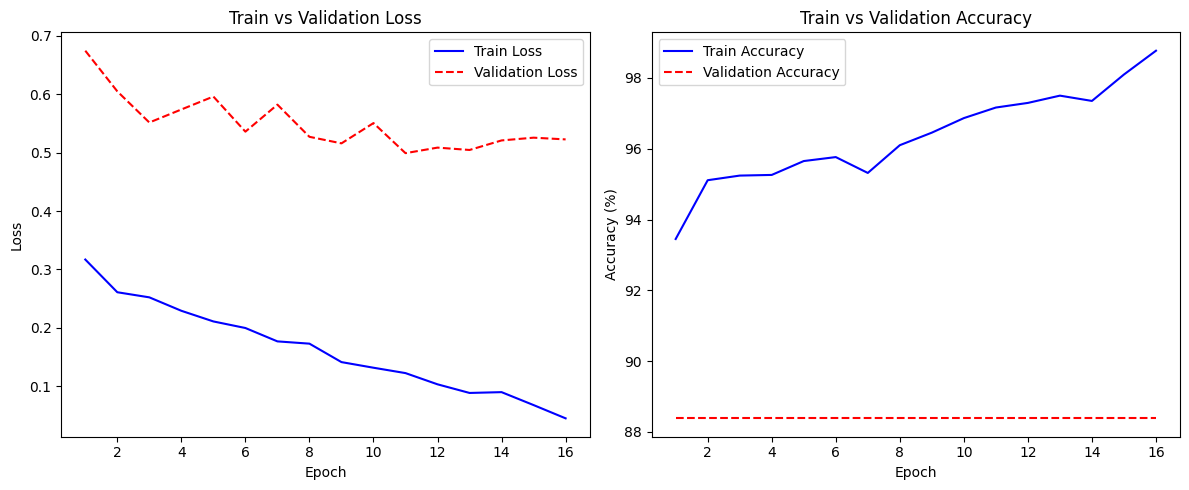


지시하신 모든 검증 기반 학습 프로세스가 완료되었습니다, 주인님.


In [3]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("그래프 생성을 위해 matplotlib 라이브러리가 필요합니다. 'pip install matplotlib' 명령어로 설치해 주십시오.")
    plt = None

# ==========================================
# 1. 설정 및 하이퍼파라미터 (주인님의 결정 영역)
# ==========================================
# 💡 훈련 데이터와 검증 데이터 CSV 경로를 각각 설정합니다.
TRAIN_CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\TrainLabels.csv"
VAL_CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\ValidationLabels.csv"
IMAGE_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\ExtractedFrames"

BATCH_SIZE = 32           
NUM_EPOCHS = 30           # 꼼꼼한 학습을 위해 에폭 상한선을 조금 높였습니다.
LEARNING_RATE = 1e-4      
WEIGHT_DECAY = 1e-4       
EARLY_STOPPING_PATIENCE = 5 # 검증 데이터 기준이므로 여유를 두어 5회로 늘렸습니다.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 이미지 기반 데이터셋 클래스
# ==========================================
class DaiseeImageDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        if not os.path.exists(csv_file):
            raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다: {csv_file}")
            
        self.labels_df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        
        # 2,3점 -> 1 (집중), 0,1점 -> 0 (비집중)
        self.labels_df['Focused'] = self.labels_df['Engagement'].apply(lambda x: 1 if x >= 2 else 0)

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        clip_id = self.labels_df.iloc[idx]['ClipID']
        clip_name = clip_id.split('.')[0] 
        
        img_path = os.path.join(self.image_dir, f"{clip_name}.jpg")
        
        try:
            with Image.open(img_path) as img:
                image = img.convert('RGB')
        except Exception:
            # 파일이 없을 경우 더미 이미지 반환
            image = Image.new('RGB', (224, 224), (0, 0, 0))
            
        label = self.labels_df.iloc[idx]['Focused']
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# 3. 모델 정의
# ==========================================
def get_binary_classification_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2) 
    return model

# ==========================================
# 4. 세밀한 학습 및 검증 루프
# ==========================================
def train():
    print(f"세밀한 학습 및 검증 프로세스를 시작합니다, 주인님. 할당된 장치: {DEVICE}")
    
    # 훈련용 전처리 (데이터 증강 기법을 추가하여 과적합을 방지할 수 있으나 기본 유지)
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(), # 💡 과적합 방지를 위해 훈련 시에만 좌우반전 추가
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # 검증용 전처리 (평가 시에는 데이터 변형 금지)
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    try:
        train_dataset = DaiseeImageDataset(csv_file=TRAIN_CSV_PATH, image_dir=IMAGE_DIR, transform=train_transform)
        val_dataset = DaiseeImageDataset(csv_file=VAL_CSV_PATH, image_dir=IMAGE_DIR, transform=val_transform)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    except Exception as e:
        print(f"데이터 로드 중 오류가 발생했습니다. 검증용 CSV 파일이 존재하는지 확인해 주십시오.\n상세 오류: {e}")
        return

    model = get_binary_classification_model().to(DEVICE)
    
    # 클래스 불균형 해소를 위한 가중치 (훈련에만 적용됨)
    class_weights = torch.tensor([2.0, 1.0]).to(DEVICE) 
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # 💡 스케줄러 기준을 검증 손실값(Validation Loss)으로 변경
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_path = "daisee_best_focus_model_val.pth"

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(NUM_EPOCHS):
        # -----------------------------
        # 1. 훈련 (Training) 단계
        # -----------------------------
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        print(f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] 훈련 시작 ---")
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            if (batch_idx + 1) % 50 == 0:
                print(f"  -> 훈련 [{batch_idx + 1}/{len(train_loader)}] 배치 처리 중... (Loss: {loss.item():.4f})")
                
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_acc = 100 * train_correct / train_total

        # -----------------------------
        # 2. 검증 (Validation) 단계
        # -----------------------------
        model.eval() # 평가 모드 전환 (Dropout, BatchNorm 고정)
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        print(f"--- Epoch [{epoch+1}/{NUM_EPOCHS}] 객관적 검증 진행 중 ---")
        with torch.no_grad(): # 검증 시에는 역전파(기울기 계산)를 하지 않아 메모리와 속도를 아낍니다.
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                outputs = model(inputs)
                # 검증 시에는 class_weights를 적용하지 않은 순수 성능을 볼 수도 있으나, 일관성을 위해 동일한 criterion 사용
                loss = criterion(outputs, labels) 
                
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_acc = 100 * val_correct / val_total
        
        # 결과 기록
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"✅ Epoch [{epoch+1}/{NUM_EPOCHS}] 결과 요약")
        print(f"  - 훈련(Train)   : Loss = {epoch_train_loss:.4f}, Accuracy = {epoch_train_acc:.2f}%")
        print(f"  - 검증(Val)     : Loss = {epoch_val_loss:.4f}, Accuracy = {epoch_val_acc:.2f}%")
        
        # -----------------------------
        # 3. 최적 모델 저장 및 조기 종료 판단 (기준: Validation Loss)
        # -----------------------------
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0 
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✨ 객관적 성능(검증 Loss)이 개선되었습니다! 새로운 최고 모델을 '{best_model_path}'에 저장했습니다.")
        else:
            patience_counter += 1
            print(f"  ⚠️ 검증 성능 개선 없음 (연속 {patience_counter}회)")
            
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"주인님의 지시대로 과적합이 시작되었다고 판단하여 학습을 조기 종료합니다.")
                break
                
        scheduler.step(epoch_val_loss)

    # ==========================================
    # 5. 세밀한 결과 비교 그래프 그리기
    # ==========================================
    if plt and history['train_loss']:
        print("\n[시스템 정보] 심층 분석용 그래프를 생성하고 있습니다...")
        epochs_range = range(1, len(history['train_loss']) + 1)

        plt.figure(figsize=(12, 5))

        # 손실값(Loss) 비교 그래프
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
        plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='red', linestyle='--')
        plt.title('Train vs Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        # 정확도(Accuracy) 비교 그래프
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue')
        plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='red', linestyle='--')
        plt.title('Train vs Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()

        plt.tight_layout()
        
        graph_save_path = "advanced_training_result_graph.png"
        plt.savefig(graph_save_path)
        print(f"[시스템 정보] 상세 비교 그래프가 '{graph_save_path}' 파일로 성공적으로 저장되었습니다.")
        
        try:
            plt.show()
        except Exception:
            pass 
            
    print("\n지시하신 모든 검증 기반 학습 프로세스가 완료되었습니다, 주인님.")

if __name__ == '__main__':
    train()

In [4]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("그래프 생성을 위해 matplotlib 라이브러리가 필요합니다. 'pip install matplotlib' 명령어로 설치해 주십시오.")
    plt = None

# ==========================================
# 1. 설정 및 하이퍼파라미터 (Heavy 모드 세팅)
# ==========================================
TRAIN_CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\TrainLabels.csv"
VAL_CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\ValidationLabels.csv"
IMAGE_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\ExtractedFrames"

# Heavy 학습에 맞춘 하이퍼파라미터 조정
BATCH_SIZE = 32           
NUM_EPOCHS = 50           # 깊은 학습을 위해 최대 50 에폭으로 확장
LEARNING_RATE = 5e-5      # 복잡한 모델이 미세하게 학습하도록 학습률을 약간 낮춤
WEIGHT_DECAY = 1e-3       # 가중치 규제(L2 정규화)를 강하게 걸어 암기 방지
EARLY_STOPPING_PATIENCE = 10 # 조기 종료 대기 횟수를 10회로 넉넉하게 확장

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 이미지 기반 데이터셋 클래스 (2진 분류 유지)
# ==========================================
class DaiseeImageDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        if not os.path.exists(csv_file):
            raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다: {csv_file}")
            
        self.labels_df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        
        # 2,3점 -> 1 (집중), 0,1점 -> 0 (비집중)
        self.labels_df['Focused'] = self.labels_df['Engagement'].apply(lambda x: 1 if x >= 2 else 0)

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        clip_id = self.labels_df.iloc[idx]['ClipID']
        clip_name = clip_id.split('.')[0] 
        
        img_path = os.path.join(self.image_dir, f"{clip_name}.jpg")
        
        try:
            with Image.open(img_path) as img:
                image = img.convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
            
        label = self.labels_df.iloc[idx]['Focused']
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# 3. 모델 정의 (ResNet50 + Dropout 추가로 Heavy하게 변경)
# ==========================================
def get_heavy_binary_classification_model():
    # 체급이 훨씬 큰 ResNet50 사용 (최신 V2 가중치 적용)
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    num_ftrs = model.fc.in_features
    
    # 모델의 마지막 층에 Dropout을 추가하여 50%의 신경망을 강제로 끄면서 가혹하게 학습시킴
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, 2)
    )
    return model

# ==========================================
# 4. 세밀하고 무거운 학습 및 검증 루프
# ==========================================
def train():
    print(f"강화된 Heavy 학습 및 검증 프로세스를 시작합니다, 주인님. 할당된 장치: {DEVICE}")
    
    # 💡 가혹한 훈련용 데이터 증강 (Data Augmentation)
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)), # 이미지를 먼저 조금 크게 만듦
        transforms.RandomCrop(224),    # 무작위로 224x224 영역을 잘라냄
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15), # 최대 15도 무작위 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # 색상, 명암 무작위 왜곡
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # 검증용은 원본 형태를 그대로 유지해야 하므로 변형하지 않음
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    try:
        train_dataset = DaiseeImageDataset(csv_file=TRAIN_CSV_PATH, image_dir=IMAGE_DIR, transform=train_transform)
        val_dataset = DaiseeImageDataset(csv_file=VAL_CSV_PATH, image_dir=IMAGE_DIR, transform=val_transform)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    except Exception as e:
        print(f"데이터 로드 중 오류가 발생했습니다.\n상세 오류: {e}")
        return

    # Heavy 모델 불러오기
    model = get_heavy_binary_classification_model().to(DEVICE)
    
    class_weights = torch.tensor([2.0, 1.0]).to(DEVICE) 
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_path = "daisee_heavy_best_focus_model.pth"

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(NUM_EPOCHS):
        # 1. 훈련 단계
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        print(f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] 훈련 시작 ---")
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            if (batch_idx + 1) % 50 == 0:
                print(f"  -> 훈련 [{batch_idx + 1}/{len(train_loader)}] 배치 처리 중... (Loss: {loss.item():.4f})")
                
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_acc = 100 * train_correct / train_total

        # 2. 검증 단계
        model.eval() 
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        print(f"--- Epoch [{epoch+1}/{NUM_EPOCHS}] 객관적 검증 진행 중 ---")
        with torch.no_grad(): 
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels) 
                
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_acc = 100 * val_correct / val_total
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"✅ Epoch [{epoch+1}/{NUM_EPOCHS}] 결과 요약")
        print(f"  - 훈련(Train)   : Loss = {epoch_train_loss:.4f}, Accuracy = {epoch_train_acc:.2f}%")
        print(f"  - 검증(Val)     : Loss = {epoch_val_loss:.4f}, Accuracy = {epoch_val_acc:.2f}%")
        
        # 3. 최적 모델 저장 및 조기 종료 판단
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0 
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✨ 검증 Loss 개선! 무거운 신경망을 견뎌낸 최고 모델을 '{best_model_path}'에 저장했습니다.")
        else:
            patience_counter += 1
            print(f"  ⚠️ 검증 성능 개선 없음 (연속 {patience_counter}회)")
            
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"주인님의 지시대로 {EARLY_STOPPING_PATIENCE}회 연속 개선이 없어 과적합 방지를 위해 학습을 조기 종료합니다.")
                break
                
        scheduler.step(epoch_val_loss)

    # 4. 결과 비교 그래프 그리기
    if plt and history['train_loss']:
        print("\n[시스템 정보] 심층 분석용 그래프를 생성하고 있습니다...")
        epochs_range = range(1, len(history['train_loss']) + 1)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
        plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='red', linestyle='--')
        plt.title('Heavy Model: Train vs Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue')
        plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='red', linestyle='--')
        plt.title('Heavy Model: Train vs Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()

        plt.tight_layout()
        
        graph_save_path = "heavy_training_result_graph.png"
        plt.savefig(graph_save_path)
        print(f"[시스템 정보] 상세 비교 그래프가 '{graph_save_path}' 파일로 성공적으로 저장되었습니다.")
        
        try:
            plt.show()
        except Exception:
            pass 
            
    print("\n지시하신 무거운(Heavy) 기반 학습 프로세스가 완료되었습니다, 주인님.")

if __name__ == '__main__':
    train()

강화된 Heavy 학습 및 검증 프로세스를 시작합니다, 주인님. 할당된 장치: cuda


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\msi/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [01:21<00:00, 1.26MB/s]



--- Epoch [1/50] 훈련 시작 ---
  -> 훈련 [50/168] 배치 처리 중... (Loss: 0.5814)
  -> 훈련 [100/168] 배치 처리 중... (Loss: 0.2883)
  -> 훈련 [150/168] 배치 처리 중... (Loss: 0.2147)
--- Epoch [1/50] 객관적 검증 진행 중 ---
✅ Epoch [1/50] 결과 요약
  - 훈련(Train)   : Loss = 0.3195, Accuracy = 93.95%
  - 검증(Val)     : Loss = 0.6154, Accuracy = 88.38%
  ✨ 검증 Loss 개선! 무거운 신경망을 견뎌낸 최고 모델을 'daisee_heavy_best_focus_model.pth'에 저장했습니다.

--- Epoch [2/50] 훈련 시작 ---
  -> 훈련 [50/168] 배치 처리 중... (Loss: 0.2228)
  -> 훈련 [100/168] 배치 처리 중... (Loss: 0.1111)
  -> 훈련 [150/168] 배치 처리 중... (Loss: 0.1903)
--- Epoch [2/50] 객관적 검증 진행 중 ---
✅ Epoch [2/50] 결과 요약
  - 훈련(Train)   : Loss = 0.2676, Accuracy = 95.35%
  - 검증(Val)     : Loss = 0.6846, Accuracy = 88.38%
  ⚠️ 검증 성능 개선 없음 (연속 1회)

--- Epoch [3/50] 훈련 시작 ---
  -> 훈련 [50/168] 배치 처리 중... (Loss: 0.4704)
  -> 훈련 [100/168] 배치 처리 중... (Loss: 0.3996)
  -> 훈련 [150/168] 배치 처리 중... (Loss: 0.2956)
--- Epoch [3/50] 객관적 검증 진행 중 ---
✅ Epoch [3/50] 결과 요약
  - 훈련(Train)   : Loss = 0.2565, Accuracy = 95.39%


KeyboardInterrupt: 

실무 투입을 위한 고도화된 모델 학습을 시작합니다, 주인님. 장치: cuda


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\msi/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth
100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:39<00:00, 1.26MB/s]



--- Epoch [1/40] 훈련 시작 ---
  -> 훈련 [50/168] 배치... (Focal Loss: 0.0819)
  -> 훈련 [100/168] 배치... (Focal Loss: 0.0142)
  -> 훈련 [150/168] 배치... (Focal Loss: 0.0397)
--- Epoch [1/40] 실무 검증(F1-Score 측정) 중 ---
✅ Epoch [1/40] 결과 요약
  - 훈련(Train)   : Focal Loss = 0.0621
  - 검증(Val)     : Focal Loss = 0.0959, F1-Score = 0.9383
  🎯 진짜 실력(F1-Score)이 향상되었습니다! 최고 모델을 'daisee_production_best_model.pth'에 덮어썼습니다.

--- Epoch [2/40] 훈련 시작 ---
  -> 훈련 [50/168] 배치... (Focal Loss: 0.0523)
  -> 훈련 [100/168] 배치... (Focal Loss: 0.0444)
  -> 훈련 [150/168] 배치... (Focal Loss: 0.0228)
--- Epoch [2/40] 실무 검증(F1-Score 측정) 중 ---
✅ Epoch [2/40] 결과 요약
  - 훈련(Train)   : Focal Loss = 0.0522
  - 검증(Val)     : Focal Loss = 0.1048, F1-Score = 0.9383
  ⚠️ F1-Score 개선 없음 (연속 1회)

--- Epoch [3/40] 훈련 시작 ---
  -> 훈련 [50/168] 배치... (Focal Loss: 0.0662)
  -> 훈련 [100/168] 배치... (Focal Loss: 0.0498)
  -> 훈련 [150/168] 배치... (Focal Loss: 0.0766)
--- Epoch [3/40] 실무 검증(F1-Score 측정) 중 ---
✅ Epoch [3/40] 결과 요약
  - 훈련(Train)   : Focal Lo

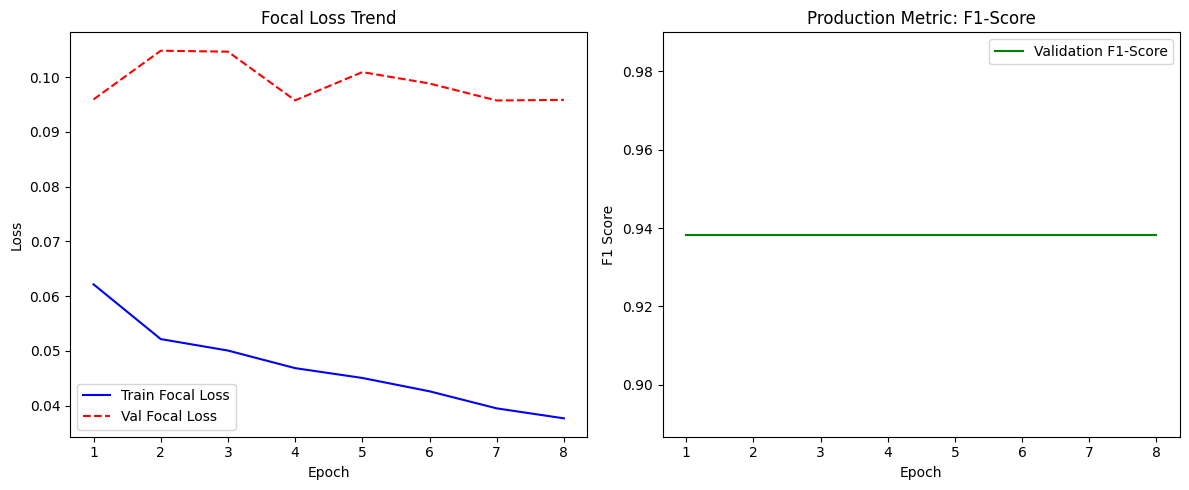

In [5]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("그래프 생성을 위해 matplotlib 라이브러리가 필요합니다.")
    plt = None

# ==========================================
# 1. 설정 및 하이퍼파라미터 (Production 세팅)
# ==========================================
TRAIN_CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\TrainLabels.csv"
VAL_CSV_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\ValidationLabels.csv"
IMAGE_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\ExtractedFrames"

BATCH_SIZE = 32           
NUM_EPOCHS = 40           
LEARNING_RATE = 3e-4      
WEIGHT_DECAY = 1e-3       
EARLY_STOPPING_PATIENCE = 7 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 실무용 손실 함수 (Focal Loss) 직접 구현
# ==========================================
class FocalLoss(nn.Module):
    """
    데이터 불균형이 심할 때, 모델이 '집중하지 않음' 상태를 
    더 집요하게 파고들도록 강제하는 손실 함수입니다.
    """
    def __init__(self, alpha=1.0, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        log_pt = -self.ce_loss(inputs, targets)
        pt = torch.exp(log_pt)
        focal_loss = -((1 - pt) ** self.gamma) * self.alpha * log_pt
        return focal_loss.mean()

# ==========================================
# 3. 데이터셋 클래스 (유지)
# ==========================================
class DaiseeImageDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        if not os.path.exists(csv_file):
            raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다: {csv_file}")
        self.labels_df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        self.labels_df['Focused'] = self.labels_df['Engagement'].apply(lambda x: 1 if x >= 2 else 0)

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        clip_id = self.labels_df.iloc[idx]['ClipID']
        clip_name = clip_id.split('.')[0] 
        img_path = os.path.join(self.image_dir, f"{clip_name}.jpg")
        
        try:
            with Image.open(img_path) as img:
                image = img.convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
            
        label = self.labels_df.iloc[idx]['Focused']
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# ==========================================
# 4. 실무용 모델 (EfficientNet-B3)
# ==========================================
def get_production_model():
    # 최신 이미지 분류 트렌드인 EfficientNet 도입
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(num_ftrs, 2)
    )
    return model

# ==========================================
# 5. 실무 적용을 위한 F1-Score 기반 학습 루프
# ==========================================
def train():
    print(f"실무 투입을 위한 고도화된 모델 학습을 시작합니다, 주인님. 장치: {DEVICE}")
    
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    try:
        train_dataset = DaiseeImageDataset(csv_file=TRAIN_CSV_PATH, image_dir=IMAGE_DIR, transform=train_transform)
        val_dataset = DaiseeImageDataset(csv_file=VAL_CSV_PATH, image_dir=IMAGE_DIR, transform=val_transform)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    except Exception as e:
        print(f"데이터 로드 중 오류가 발생했습니다.\n상세 오류: {e}")
        return

    model = get_production_model().to(DEVICE)
    
    # 💡 CrossEntropy 대신 Focal Loss 사용
    criterion = FocalLoss(alpha=1.0, gamma=2.0).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # 💡 Cosine Annealing 스케줄러로 매너리즘 방지
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    
    # 💡 실무 학습 가속 및 안정화를 위한 혼합 정밀도(AMP) 스케일러
    scaler = torch.amp.GradScaler('cuda' if torch.cuda.is_available() else 'cpu')
    
    best_val_f1 = 0.0 # Loss 대신 F1-Score 기준으로 베스트 모델 판별
    patience_counter = 0
    best_model_path = "daisee_production_best_model.pth"

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    
    for epoch in range(NUM_EPOCHS):
        # --- 훈련 단계 ---
        model.train()
        running_train_loss = 0.0
        
        print(f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] 훈련 시작 ---")
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            
            # AMP 적용 구간
            with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_train_loss += loss.item()
            
            if (batch_idx + 1) % 50 == 0:
                print(f"  -> 훈련 [{batch_idx + 1}/{len(train_loader)}] 배치... (Focal Loss: {loss.item():.4f})")
                
        epoch_train_loss = running_train_loss / len(train_loader)

        # --- 검증 단계 (F1-Score 직접 계산) ---
        model.eval() 
        running_val_loss = 0.0
        
        # F1 Score 계산용 변수
        tp, fp, fn = 0, 0, 0 
        
        print(f"--- Epoch [{epoch+1}/{NUM_EPOCHS}] 실무 검증(F1-Score 측정) 중 ---")
        with torch.no_grad(): 
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels) 
                
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                
                # F1 Score 요소 계산
                preds = predicted == 1
                targets = labels == 1
                tp += (preds & targets).sum().item()
                fp += (preds & ~targets).sum().item()
                fn += (~preds & targets).sum().item()
                
        epoch_val_loss = running_val_loss / len(val_loader)
        
        # 💡 F1 Score 계산 로직
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        epoch_val_f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_f1'].append(epoch_val_f1)

        print(f"✅ Epoch [{epoch+1}/{NUM_EPOCHS}] 결과 요약")
        print(f"  - 훈련(Train)   : Focal Loss = {epoch_train_loss:.4f}")
        print(f"  - 검증(Val)     : Focal Loss = {epoch_val_loss:.4f}, F1-Score = {epoch_val_f1:.4f}")
        
        # --- 최적 모델 저장 및 조기 종료 판단 (기준: F1-Score) ---
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            patience_counter = 0 
            torch.save(model.state_dict(), best_model_path)
            print(f"  🎯 진짜 실력(F1-Score)이 향상되었습니다! 최고 모델을 '{best_model_path}'에 덮어썼습니다.")
        else:
            patience_counter += 1
            print(f"  ⚠️ F1-Score 개선 없음 (연속 {patience_counter}회)")
            
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"주인님의 지시대로 과적합 방지를 위해 실무 모델 학습을 완료합니다.")
                break
                
        scheduler.step()

    # --- 그래프 도출 ---
    if plt and history['train_loss']:
        print("\n[시스템 정보] 실무 성능 분석용 그래프를 생성합니다...")
        epochs_range = range(1, len(history['train_loss']) + 1)
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, history['train_loss'], label='Train Focal Loss', color='blue')
        plt.plot(epochs_range, history['val_loss'], label='Val Focal Loss', color='red', linestyle='--')
        plt.title('Focal Loss Trend')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, history['val_f1'], label='Validation F1-Score', color='green')
        plt.title('Production Metric: F1-Score')
        plt.xlabel('Epoch')
        plt.ylabel('F1 Score')
        plt.legend()

        plt.tight_layout()
        graph_save_path = "production_training_result.png"
        plt.savefig(graph_save_path)
        print(f"[시스템 정보] 결과 그래프가 '{graph_save_path}'로 저장되었습니다.")
            
    print("\n지시하신 실무형(Production-Ready) 집중도 분석 모델 학습이 모두 완료되었습니다, 주인님.")

if __name__ == '__main__':
    train()

In [6]:
import os
import cv2
import pandas as pd
import numpy as np
import mediapipe as mp
from tqdm import tqdm

# ==========================================
# 1. 경로 설정
# ==========================================
DATA_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\DataSet"
SAVE_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features"
os.makedirs(SAVE_DIR, exist_ok=True)

CSV_FILES = {
    "train": r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\TrainLabels.csv",
    "val": r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\ValidationLabels.csv"
}

# ==========================================
# 2. MediaPipe 세팅 및 추출 설정
# ==========================================
mp_face_mesh = mp.solutions.face_mesh
# 분석할 10개의 핵심 얼굴 좌표: 코끝, 양쪽 눈, 입술 끝, 턱 등
KEY_LANDMARKS = [1, 33, 133, 362, 263, 13, 14, 78, 308, 152]
NUM_FRAMES_TO_SAMPLE = 5 # 비디오당 5장의 프레임을 일정한 간격으로 추출

def extract_features_from_csv(csv_path, split_name):
    print(f"\n[{split_name.upper()}] 데이터셋 안면 특징점 추출 시작...")
    df = pd.read_csv(csv_path)
    
    # 결과를 저장할 리스트
    extracted_data = []

    with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=False) as face_mesh:
        for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name} 처리 중"):
            clip_id = row['ClipID']
            clip_name = clip_id.split('.')[0]
            subject_id = clip_name[:6]
            label = 1 if row['Engagement'] >= 2 else 0
            
            # 파일 경로 유연하게 탐색
            possible_paths = [
                os.path.join(DATA_DIR, subject_id, clip_name, clip_id),
                os.path.join(DATA_DIR, subject_id, clip_name, f"{clip_name}.mp4"),
                os.path.join(DATA_DIR, "Train" if split_name=="train" else "Validation", subject_id, clip_name, clip_id),
                os.path.join(DATA_DIR, "Train" if split_name=="train" else "Validation", subject_id, clip_name, f"{clip_name}.mp4")
            ]
            
            video_path = next((p for p in possible_paths if os.path.exists(p)), None)
            
            # 비디오를 못 찾거나 프레임을 못 읽었을 때 쓸 기본값 (0.0)
            empty_features = [0.0] * (NUM_FRAMES_TO_SAMPLE * len(KEY_LANDMARKS) * 3)
            
            if not video_path:
                extracted_data.append([clip_id] + empty_features + [label])
                continue
                
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            if total_frames < NUM_FRAMES_TO_SAMPLE:
                cap.release()
                extracted_data.append([clip_id] + empty_features + [label])
                continue

            # 일정한 간격으로 5장의 프레임 인덱스 계산
            frame_indices = np.linspace(0, total_frames - 1, NUM_FRAMES_TO_SAMPLE, dtype=int)
            video_features = []
            
            for f_idx in frame_indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
                ret, frame = cap.read()
                if not ret:
                    video_features.extend([0.0] * (len(KEY_LANDMARKS) * 3))
                    continue
                    
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = face_mesh.process(frame_rgb)
                
                if results.multi_face_landmarks:
                    landmarks = results.multi_face_landmarks[0].landmark
                    for lm_idx in KEY_LANDMARKS:
                        lm = landmarks[lm_idx]
                        video_features.extend([lm.x, lm.y, lm.z])
                else:
                    # 얼굴을 인식하지 못한 경우 (화면 밖으로 나감 등) -> 이 역시 중요한 집중력 상실의 단서
                    video_features.extend([0.0] * (len(KEY_LANDMARKS) * 3))
                    
            cap.release()
            extracted_data.append([clip_id] + video_features + [label])
            
    # 추출된 데이터를 CSV로 저장
    columns = ['ClipID'] + [f'feat_{i}' for i in range(NUM_FRAMES_TO_SAMPLE * len(KEY_LANDMARKS) * 3)] + ['Focused']
    result_df = pd.DataFrame(extracted_data, columns=columns)
    
    save_path = os.path.join(SAVE_DIR, f"{split_name}_mediapipe_features.csv")
    result_df.to_csv(save_path, index=False)
    print(f"[{split_name.upper()}] 추출 완료! 저장 위치: {save_path}")

if __name__ == '__main__':
    extract_features_from_csv(CSV_FILES['train'], 'train')
    extract_features_from_csv(CSV_FILES['val'], 'val')
    print("주인님, 모든 데이터의 수치화 작업이 성공적으로 완료되었습니다.")


[TRAIN] 데이터셋 안면 특징점 추출 시작...


train 처리 중:   0%|                                                                                                 | 0/5358 [00:00<?, ?it/s]F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\.venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
train 처리 중: 100%|██████████████████████████████████████████████████████████████████████████████████████| 5358/5358 [07:53<00:00, 11.32it/s]


[TRAIN] 추출 완료! 저장 위치: F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\train_mediapipe_features.csv

[VAL] 데이터셋 안면 특징점 추출 시작...


val 처리 중:   0%|                                                                                                   | 0/1429 [00:00<?, ?it/s]F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\.venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
val 처리 중: 100%|████████████████████████████████████████████████████████████████████████████████████████| 1429/1429 [02:01<00:00, 11.72it/s]


[VAL] 추출 완료! 저장 위치: F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\val_mediapipe_features.csv
주인님, 모든 데이터의 수치화 작업이 성공적으로 완료되었습니다.


In [8]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

# ==========================================
# 1. 경로 및 설정
# ==========================================
TRAIN_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\train_mediapipe_features.csv"
VAL_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\val_mediapipe_features.csv"

BATCH_SIZE = 64 # 데이터가 매우 가벼워지므로 배치를 늘려도 전혀 부담이 없습니다.
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
EARLY_STOPPING_PATIENCE = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 정형 데이터(CSV) 전용 데이터셋
# ==========================================
class TabularDataset(Dataset):
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)
        # 1열은 ClipID, 마지막 열은 Label, 중간은 150개의 특징(Feature)
        self.features = df.iloc[:, 1:-1].values.astype('float32')
        self.labels = df.iloc[:, -1].values.astype('int64')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.labels[idx])

# ==========================================
# 3. 경량 다층 퍼셉트론 (MLP) 모델
# ==========================================
class FocusMLP(nn.Module):
    def __init__(self, input_dim=150): # 5장 * 10개좌표 * 3D(x,y,z) = 150
        super(FocusMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4), # 과적합 방지
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 4. 투명한 검증 기반 학습 루프
# ==========================================
def train():
    print(f"실무용 수치 기반 딥러닝 학습을 시작합니다, 주인님. 할당된 장치: {DEVICE}")
    
    try:
        train_dataset = TabularDataset(TRAIN_FEAT_PATH)
        val_dataset = TabularDataset(VAL_FEAT_PATH)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    except Exception as e:
        print(f"특징점 데이터 로드 중 오류 발생. 1단계 스크립트를 먼저 실행하셨는지 확인해 주십시오.\n오류: {e}")
        return

    model = FocusMLP(input_dim=150).to(DEVICE)
    
    # 💡 극강의 불균형 해소: 모델이 '비집중(0)'을 5배 더 중요하게 인식하도록 강제합니다.
    class_weights = torch.tensor([5.0, 1.0]).to(DEVICE) 
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_path = "daisee_production_mlp_best.pth"

    for epoch in range(NUM_EPOCHS):
        # --- 훈련 단계 ---
        model.train()
        running_train_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
                
        epoch_train_loss = running_train_loss / len(train_loader)

        # --- 검증 단계 ---
        model.eval() 
        running_val_loss = 0.0
        tp, fp, fn, tn = 0, 0, 0, 0 # 모델의 꼼수를 막기 위한 투명한 지표 추적
        
        with torch.no_grad(): 
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels) 
                running_val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                
                preds = predicted == 1
                targets = labels == 1
                tp += (preds & targets).sum().item()
                fp += (preds & ~targets).sum().item()
                fn += (~preds & targets).sum().item()
                tn += (~preds & ~targets).sum().item() 
                
        epoch_val_loss = running_val_loss / len(val_loader)
        
        # 💡 F1 Score 및 정확도 계산
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)
        accuracy = 100 * (tp + tn) / (tp + fp + fn + tn)

        print(f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] 완료 ---")
        print(f"  [손실값] Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        print(f"  [투명 지표] 🎯정답(집중): {tp}명 | 🎯정답(비집중): {tn}명 | ❌오답(집중이라 착각): {fp}명 | ❌오답(비집중이라 착각): {fn}명")
        print(f"  [종합 평가] 정확도: {accuracy:.2f}% | F1-Score: {f1_score:.4f}")
        
        # 최적 모델 저장 (기준: Validation Loss 감소율)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0 
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✨ 성능 개선! 모델을 '{best_model_path}'에 덮어썼습니다.")
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"  ⚠️ {EARLY_STOPPING_PATIENCE}회 연속 개선이 없어 과적합 방지를 위해 학습을 조기 종료합니다.")
                break
                
        scheduler.step(epoch_val_loss)

    print("\n지시하신 모든 실무 파이프라인(MediaPipe+MLP) 작업이 완료되었습니다, 주인님.")

if __name__ == '__main__':
    train()

실무용 수치 기반 딥러닝 학습을 시작합니다, 주인님. 할당된 장치: cuda

--- Epoch [1/50] 완료 ---
  [손실값] Train Loss: 0.5276 | Val Loss: 0.7609
  [투명 지표] 🎯정답(집중): 1155명 | 🎯정답(비집중): 8명 | ❌오답(집중이라 착각): 158명 | ❌오답(비집중이라 착각): 108명
  [종합 평가] 정확도: 81.39% | F1-Score: 0.8967
  ✨ 성능 개선! 모델을 'daisee_production_mlp_best.pth'에 덮어썼습니다.

--- Epoch [2/50] 완료 ---
  [손실값] Train Loss: 0.4965 | Val Loss: 0.7611
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383

--- Epoch [3/50] 완료 ---
  [손실값] Train Loss: 0.4781 | Val Loss: 0.7172
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383
  ✨ 성능 개선! 모델을 'daisee_production_mlp_best.pth'에 덮어썼습니다.

--- Epoch [4/50] 완료 ---
  [손실값] Train Loss: 0.4828 | Val Loss: 0.7066
  [투명 지표] 🎯정답(집중): 1217명 | 🎯정답(비집중): 18명 | ❌오답(집중이라 착각): 148명 | ❌오답(비집중이라 착각): 46명
  [종합 평가] 정확도: 86.42% | F1-Score: 0.9262
  ✨ 성능 개선! 모델을 'daisee_production_mlp_best.pth'에 덮어썼습니다.

--- Epoch

In [9]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

# ==========================================
# 1. 경로 및 설정
# ==========================================
TRAIN_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\train_mediapipe_features.csv"
VAL_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\val_mediapipe_features.csv"

BATCH_SIZE = 64 
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 시계열 전용 데이터셋 (Sequence Dataset)
# ==========================================
class TimeSeriesDataset(Dataset):
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)
        
        # 150개의 Feature 추출
        features_1d = df.iloc[:, 1:-1].values.astype('float32')
        
        # 💡 핵심 재설계: (Batch, 150) -> (Batch, 5, 30) 으로 형태 변경
        # 5장의 프레임(시간)마다 30개(10개 랜드마크 * 3차원)의 좌표가 흐르도록 재배열합니다.
        self.features = features_1d.reshape(-1, 5, 30)
        
        self.labels = df.iloc[:, -1].values.astype('int64')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.labels[idx])

# ==========================================
# 3. 시간의 흐름을 읽는 모델 (LSTM)
# ==========================================
class FocusLSTM(nn.Module):
    def __init__(self, input_size=30, hidden_size=64, num_layers=2, num_classes=2):
        super(FocusLSTM, self).__init__()
        
        # LSTM 레이어: 이전 프레임의 맥락(Context)을 기억합니다.
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=0.3
        )
        
        # 최종 판단을 내리는 분류기
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, 5 frames, 30 features)
        lstm_out, (hn, cn) = self.lstm(x)
        
        # lstm_out shape: (Batch, 5, hidden_size)
        # 💡 5번의 시간 변화를 모두 지켜본 뒤, 가장 마지막(5번째) 프레임의 출력값만 사용해 최종 판단을 내립니다.
        last_time_step_out = lstm_out[:, -1, :] 
        
        return self.classifier(last_time_step_out)

# ==========================================
# 4. 시계열 기반 실무 학습 루프
# ==========================================
def train():
    print(f"시간의 흐름을 읽는 LSTM 모델 재설계 및 학습을 시작합니다, 주인님. 할당된 장치: {DEVICE}")
    
    try:
        train_dataset = TimeSeriesDataset(TRAIN_FEAT_PATH)
        val_dataset = TimeSeriesDataset(VAL_FEAT_PATH)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    except Exception as e:
        print(f"데이터 로드 중 오류가 발생했습니다.\n오류: {e}")
        return

    model = FocusLSTM().to(DEVICE)
    
    # 💡 극강의 불균형 해소 유지
    class_weights = torch.tensor([5.0, 1.0]).to(DEVICE) 
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_path = "daisee_production_lstm_best.pth"

    for epoch in range(NUM_EPOCHS):
        # --- 훈련 단계 ---
        model.train()
        running_train_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
                
        epoch_train_loss = running_train_loss / len(train_loader)

        # --- 검증 단계 ---
        model.eval() 
        running_val_loss = 0.0
        tp, fp, fn, tn = 0, 0, 0, 0 
        
        with torch.no_grad(): 
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels) 
                running_val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                
                preds = predicted == 1
                targets = labels == 1
                tp += (preds & targets).sum().item()
                fp += (preds & ~targets).sum().item()
                fn += (~preds & targets).sum().item()
                tn += (~preds & ~targets).sum().item() 
                
        epoch_val_loss = running_val_loss / len(val_loader)
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)
        accuracy = 100 * (tp + tn) / (tp + fp + fn + tn)

        print(f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] 완료 ---")
        print(f"  [손실값] Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        print(f"  [투명 지표] 🎯정답(집중): {tp}명 | 🎯정답(비집중): {tn}명 | ❌오답(집중이라 착각): {fp}명 | ❌오답(비집중이라 착각): {fn}명")
        print(f"  [종합 평가] 정확도: {accuracy:.2f}% | F1-Score: {f1_score:.4f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0 
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✨ 성능 개선! 시간의 맥락을 이해한 최고 모델을 '{best_model_path}'에 덮어썼습니다.")
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"  ⚠️ {EARLY_STOPPING_PATIENCE}회 연속 개선이 없어 과적합 방지를 위해 학습을 조기 종료합니다.")
                break
                
        scheduler.step(epoch_val_loss)

    print("\nLSTM 시계열 모델 학습 파이프라인 작업이 완료되었습니다, 주인님.")

if __name__ == '__main__':
    train()

시간의 흐름을 읽는 LSTM 모델 재설계 및 학습을 시작합니다, 주인님. 할당된 장치: cuda

--- Epoch [1/50] 완료 ---
  [손실값] Train Loss: 0.5474 | Val Loss: 0.6564
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383
  ✨ 성능 개선! 시간의 맥락을 이해한 최고 모델을 'daisee_production_lstm_best.pth'에 덮어썼습니다.

--- Epoch [2/50] 완료 ---
  [손실값] Train Loss: 0.5160 | Val Loss: 0.6677
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383

--- Epoch [3/50] 완료 ---
  [손실값] Train Loss: 0.4993 | Val Loss: 0.6695
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383

--- Epoch [4/50] 완료 ---
  [손실값] Train Loss: 0.5031 | Val Loss: 0.6689
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383

--- Epoch [5/50] 완료 ---
  [손실값] Train Loss: 0.5043 | Val Loss: 0.6624
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답

In [10]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
try:
    from sklearn.preprocessing import StandardScaler
except ImportError:
    print("스케일링을 위해 scikit-learn 라이브러리가 필요합니다. 터미널에 'pip install scikit-learn'을 입력해 주십시오.")
    StandardScaler = None

# ==========================================
# 1. 경로 및 설정
# ==========================================
TRAIN_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\train_mediapipe_features.csv"
VAL_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\val_mediapipe_features.csv"

BATCH_SIZE = 64 
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 2. 실무용 손실 함수 (Focal Loss 복구)
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0): # 비집중에 더 큰 강제력을 부여하기 위해 파라미터 미세 조정
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        log_pt = -self.ce_loss(inputs, targets)
        pt = torch.exp(log_pt)
        focal_loss = -((1 - pt) ** self.gamma) * self.alpha * log_pt
        return focal_loss.mean()

# ==========================================
# 3. 데이터 로드 및 정규화(Scaling) 전처리
# ==========================================
def load_and_scale_data(train_csv, val_csv):
    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)
    
    # 특징(Features)과 라벨(Labels) 분리
    X_train = train_df.iloc[:, 1:-1].values.astype('float32')
    y_train = train_df.iloc[:, -1].values.astype('int64')
    
    X_val = val_df.iloc[:, 1:-1].values.astype('float32')
    y_val = val_df.iloc[:, -1].values.astype('int64')
    
    # 💡 핵심 재설계: StandardScaler를 통한 데이터 정규화
    if StandardScaler:
        scaler = StandardScaler()
        # 기준은 반드시 Train 데이터로 잡고, Val 데이터는 Train의 기준에 맞춰 변환만 합니다.
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        
    # (Batch, 150) -> (Batch, 5, 30) 형태로 변환 (5프레임 * 30좌표)
    X_train = X_train.reshape(-1, 5, 30)
    X_val = X_val.reshape(-1, 5, 30)
    
    return X_train, y_train, X_val, y_val

class TimeSeriesDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.labels[idx])

# ==========================================
# 4. 시간의 흐름을 읽는 모델 (LSTM)
# ==========================================
class FocusLSTM(nn.Module):
    def __init__(self, input_size=30, hidden_size=64, num_layers=2, num_classes=2):
        super(FocusLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step_out = lstm_out[:, -1, :] 
        return self.classifier(last_time_step_out)

# ==========================================
# 5. 스케일링 & 클리핑이 적용된 강력한 학습 루프
# ==========================================
def train():
    print(f"스케일링 및 Focal Loss가 적용된 LSTM 실무 학습을 시작합니다, 주인님. 할당 장치: {DEVICE}")
    
    try:
        X_train, y_train, X_val, y_val = load_and_scale_data(TRAIN_FEAT_PATH, VAL_FEAT_PATH)
        
        train_dataset = TimeSeriesDataset(X_train, y_train)
        val_dataset = TimeSeriesDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    except Exception as e:
        print(f"데이터 로드 중 오류가 발생했습니다.\n오류: {e}")
        return

    model = FocusLSTM().to(DEVICE)
    
    # Focal Loss 적용
    criterion = FocalLoss().to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_path = "daisee_production_lstm_scaled_best.pth"

    for epoch in range(NUM_EPOCHS):
        # --- 훈련 단계 ---
        model.train()
        running_train_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # 💡 핵심 안전장치: LSTM의 기울기 폭발을 막는 Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_train_loss += loss.item()
                
        epoch_train_loss = running_train_loss / len(train_loader)

        # --- 검증 단계 ---
        model.eval() 
        running_val_loss = 0.0
        tp, fp, fn, tn = 0, 0, 0, 0 
        
        with torch.no_grad(): 
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels) 
                running_val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                
                preds = predicted == 1
                targets = labels == 1
                tp += (preds & targets).sum().item()
                fp += (preds & ~targets).sum().item()
                fn += (~preds & targets).sum().item()
                tn += (~preds & ~targets).sum().item() 
                
        epoch_val_loss = running_val_loss / len(val_loader)
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)
        accuracy = 100 * (tp + tn) / (tp + fp + fn + tn)

        print(f"\n--- Epoch [{epoch+1}/{NUM_EPOCHS}] 완료 ---")
        print(f"  [손실값] Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        print(f"  [투명 지표] 🎯정답(집중): {tp}명 | 🎯정답(비집중): {tn}명 | ❌오답(집중이라 착각): {fp}명 | ❌오답(비집중이라 착각): {fn}명")
        print(f"  [종합 평가] 정확도: {accuracy:.2f}% | F1-Score: {f1_score:.4f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0 
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✨ 성능 개선! 정규화된 시계열 최고 모델을 '{best_model_path}'에 덮어썼습니다.")
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"  ⚠️ {EARLY_STOPPING_PATIENCE}회 연속 개선이 없어 과적합 방지를 위해 학습을 조기 종료합니다.")
                break
                
        scheduler.step(epoch_val_loss)

    print("\n최종 재설계된 LSTM 시계열 모델 학습 파이프라인 작업이 완료되었습니다, 주인님.")

if __name__ == '__main__':
    train()

스케일링 및 Focal Loss가 적용된 LSTM 실무 학습을 시작합니다, 주인님. 할당 장치: cuda

--- Epoch [1/50] 완료 ---
  [손실값] Train Loss: 0.0571 | Val Loss: 0.0834
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383
  ✨ 성능 개선! 정규화된 시계열 최고 모델을 'daisee_production_lstm_scaled_best.pth'에 덮어썼습니다.

--- Epoch [2/50] 완료 ---
  [손실값] Train Loss: 0.0436 | Val Loss: 0.0832
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383
  ✨ 성능 개선! 정규화된 시계열 최고 모델을 'daisee_production_lstm_scaled_best.pth'에 덮어썼습니다.

--- Epoch [3/50] 완료 ---
  [손실값] Train Loss: 0.0412 | Val Loss: 0.0725
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명 | ❌오답(비집중이라 착각): 0명
  [종합 평가] 정확도: 88.38% | F1-Score: 0.9383
  ✨ 성능 개선! 정규화된 시계열 최고 모델을 'daisee_production_lstm_scaled_best.pth'에 덮어썼습니다.

--- Epoch [4/50] 완료 ---
  [손실값] Train Loss: 0.0411 | Val Loss: 0.0798
  [투명 지표] 🎯정답(집중): 1263명 | 🎯정답(비집중): 0명 | ❌오답(집중이라 착각): 166명

In [17]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

# ==========================================
# 1. 경로 설정 (명확한 Train/Val 분리 로드)
# ==========================================
TRAIN_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\train_mediapipe_features.csv"
VAL_FEAT_PATH = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Features\val_mediapipe_features.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 배치 사이즈를 256으로 줄여 GPU가 가중치를 더 자주, 신중하게 업데이트하도록 유도합니다. (주인님 판단하에 수정 가능)
BATCH_SIZE = 256 
EPOCHS = 100

# ==========================================
# 2. 데이터 전처리 재설계 (Data Leakage 방지 및 스케일링)
# ==========================================
def load_and_preprocess_data(train_path, val_path):
    print("🔍 [전처리 1단계] Train / Val 데이터 철저히 분리 로드 중...")
    
    if not os.path.exists(train_path) or not os.path.exists(val_path):
        raise FileNotFoundError("❌ 특징점 CSV 파일을 찾을 수 없습니다. 경로를 확인해 주십시오.")

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)

    # 특성(X)과 라벨(y) 분리
    X_train = train_df.iloc[:, 1:-1].values.astype(np.float32)
    y_train = train_df.iloc[:, -1].values.astype(np.float32)
    
    X_val = val_df.iloc[:, 1:-1].values.astype(np.float32)
    y_val = val_df.iloc[:, -1].values.astype(np.float32)

    print("⚖️ [전처리 2단계] StandardScaler 적용 (데이터 누수 방지를 위해 Train 기준으로만 정규화)")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    print(f"✅ 전처리 완료: Train 샘플 {X_train.shape[0]}개 | Val 샘플 {X_val.shape[0]}개")
    return X_train, y_train, X_val, y_val

# ==========================================
# 3. 모델 정의 (주인님의 Deep Residual MLP)
# ==========================================
class IntensiveModel(nn.Module):
    def __init__(self, input_dim):
        super(IntensiveModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.3)
        )
        self.res_block = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512)
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.SiLU(),
            nn.Dropout(0.3), 
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        feat = self.net(x)
        res = self.res_block(feat)
        combined = torch.relu(feat + res)
        return self.classifier(combined)

# ==========================================
# 4. 학습 루프
# ==========================================
def run():
    try:
        X_train, y_train, X_val, y_val = load_and_preprocess_data(TRAIN_FEAT_PATH, VAL_FEAT_PATH)
    except Exception as e:
        print(f"❗ 에러 발생: {e}")
        return

    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1, 1))
    val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val).view(-1, 1))
    
    print("🎯 [전처리 3단계] 데이터 불균형 해결을 위한 WeightedRandomSampler 적용")
    class_counts = np.bincount(y_train.astype(int))
    print(f"   -> 원본 Train 분포: 비집중(0) {class_counts[0]}개 / 집중(1) {class_counts[1]}개")
    
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[y_train.astype(int)]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    # DataLoader 생성
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    model = IntensiveModel(X_train.shape[1]).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    criterion = nn.BCELoss()
    
    # GPU 실제 작동 여부 확인용 로그
    if torch.cuda.is_available():
        print(f"\n🖥️ 할당된 GPU 장치명: {torch.cuda.get_device_name(0)}")
    print(f"🚀 {DEVICE}에서 본격적인 학습을 시작합니다, 주인님.\n")
    
    best_f1 = 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                out = model(batch_x.to(DEVICE))
                preds.extend((out > 0.5).float().cpu().numpy().flatten())
                actuals.extend(batch_y.numpy().flatten())
        
        # 꼼수 확인을 위한 세부 지표 계산
        preds = np.array(preds)
        actuals = np.array(actuals)
        
        tp = np.sum((preds == 1) & (actuals == 1))
        tn = np.sum((preds == 0) & (actuals == 0))
        fp = np.sum((preds == 1) & (actuals == 0))
        fn = np.sum((preds == 0) & (actuals == 1))
        
        score = f1_score(actuals, preds)
        avg_train_loss = running_loss / len(train_loader)
        
        if score > best_f1:
            best_f1 = score
            torch.save(model.state_dict(), "daisee_intensive_mlp_best.pth")
            print(f"🔥 Epoch {epoch:02d} [Loss: {avg_train_loss:.4f}] - F1: {score:.4f} | 정답(비집중:{tn}/집중:{tp}) | 오답(비집중착각:{fn}/집중착각:{fp}) (Saved!)")
        elif epoch % 5 == 0:
            print(f"   Epoch {epoch:02d} [Loss: {avg_train_loss:.4f}] - F1: {score:.4f} | 정답(비집중:{tn}/집중:{tp})")

    print("\n지시하신 모든 데이터 전처리 및 학습 프로세스가 완료되었습니다.")

if __name__ == "__main__":
    run()

🔍 [전처리 1단계] Train / Val 데이터 철저히 분리 로드 중...
⚖️ [전처리 2단계] StandardScaler 적용 (데이터 누수 방지를 위해 Train 기준으로만 정규화)
✅ 전처리 완료: Train 샘플 5358개 | Val 샘플 1429개
🎯 [전처리 3단계] 데이터 불균형 해결을 위한 WeightedRandomSampler 적용
   -> 원본 Train 분포: 비집중(0) 247개 / 집중(1) 5111개

🖥️ 할당된 GPU 장치명: NVIDIA GeForce RTX 4060 Laptop GPU
🚀 cuda에서 본격적인 학습을 시작합니다, 주인님.

🔥 Epoch 01 [Loss: 0.6334] - F1: 0.6979 | 정답(비집중:108/집중:708) | 오답(비집중착각:555/집중착각:58) (Saved!)
🔥 Epoch 02 [Loss: 0.5789] - F1: 0.7954 | 정답(비집중:75/집중:894) | 오답(비집중착각:369/집중착각:91) (Saved!)
   Epoch 05 [Loss: 0.5173] - F1: 0.7835 | 정답(비집중:69/집중:876)
🔥 Epoch 08 [Loss: 0.4699] - F1: 0.8051 | 정답(비집중:59/집중:923) | 오답(비집중착각:340/집중착각:107) (Saved!)
   Epoch 10 [Loss: 0.4144] - F1: 0.7790 | 정답(비집중:67/집중:869)
🔥 Epoch 11 [Loss: 0.4053] - F1: 0.8080 | 정답(비집중:60/집중:928) | 오답(비집중착각:335/집중착각:106) (Saved!)
🔥 Epoch 12 [Loss: 0.3996] - F1: 0.8187 | 정답(비집중:54/집중:953) | 오답(비집중착각:310/집중착각:112) (Saved!)
🔥 Epoch 14 [Loss: 0.3686] - F1: 0.8384 | 정답(비집중:38/집중:1004) | 오답(비집중착각:259/집중착각:128) (Save

In [19]:
import os
import cv2
import pandas as pd
from tqdm import tqdm

# ==========================================
# 1. 경로 설정 (원본 데이터 및 출력 폴더)
# ==========================================
RAW_DATA_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\DataSet"
TRAIN_LABEL_CSV = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\TrainLabels.csv"
VAL_LABEL_CSV = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Labels\ValidationLabels.csv"

# 새롭게 정제된 데이터가 저장될 최상위 폴더
OUTPUT_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Preprocessed_ImageFolder"

# ==========================================
# 2. 클래스별 폴더 생성 (PyTorch ImageFolder 구조)
# ==========================================
def create_directory_structure():
    splits = ['Train', 'Validation']
    classes = ['0_Unfocused', '1_Focused']
    
    for split in splits:
        for cls in classes:
            path = os.path.join(OUTPUT_DIR, split, cls)
            os.makedirs(path, exist_ok=True)
            
    print(f"📁 출력 폴더 구조가 '{OUTPUT_DIR}'에 준비되었습니다.")

# ==========================================
# 3. Raw 비디오 -> 프레임 추출 및 분류 로직
# ==========================================
def process_videos(csv_path, split_name):
    if not os.path.exists(csv_path):
        print(f"❌ 라벨 CSV 파일을 찾을 수 없습니다: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    # 2,3점 -> 1(집중), 0,1점 -> 0(비집중)
    df['Focused'] = df['Engagement'].apply(lambda x: 1 if x >= 2 else 0)
    
    success_count = 0
    fail_count = 0

    print(f"\n🔄 [{split_name}] 데이터 전처리를 시작합니다...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name} 전처리 중"):
        clip_id = row['ClipID']
        clip_name = clip_id.split('.')[0]
        subject_id = clip_name[:6]
        label = row['Focused']
        
        # 라벨에 따른 저장 폴더 결정
        folder_name = '1_Focused' if label == 1 else '0_Unfocused'
        save_path = os.path.join(OUTPUT_DIR, split_name, folder_name, f"{clip_name}.jpg")
        
        # 이미 전처리된 파일이 있다면 건너뜀 (중단 후 재개 가능)
        if os.path.exists(save_path):
            success_count += 1
            continue

        # 원본 데이터 폴더 구조의 변수(확장자, 하위폴더 등)를 모두 고려한 탐색
        sub_folder = "Train" if split_name == "Train" else "Validation"
        possible_paths = [
            os.path.join(RAW_DATA_DIR, subject_id, clip_name, clip_id),
            os.path.join(RAW_DATA_DIR, subject_id, clip_name, f"{clip_name}.mp4"),
            os.path.join(RAW_DATA_DIR, sub_folder, subject_id, clip_name, clip_id),
            os.path.join(RAW_DATA_DIR, sub_folder, subject_id, clip_name, f"{clip_name}.mp4")
        ]
        
        video_path = next((p for p in possible_paths if os.path.exists(p)), None)
        
        if not video_path:
            fail_count += 1
            continue
            
        # 비디오에서 노이즈가 적은 중간 프레임을 1장 추출
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames > 10:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(total_frames / 2))
            
        ret, frame = cap.read()
        cap.release()
        
        if ret:
            # OpenCV로 성공적으로 읽었을 경우 JPG로 저장
            cv2.imwrite(save_path, frame)
            success_count += 1
        else:
            fail_count += 1

    print(f"✅ [{split_name}] 전처리 완료: 성공 {success_count}건, 실패/누락 {fail_count}건")

# ==========================================
# 4. 실행
# ==========================================
if __name__ == '__main__':
    create_directory_structure()
    process_videos(TRAIN_LABEL_CSV, 'Train')
    process_videos(VAL_LABEL_CSV, 'Validation')
    print("\n주인님, 지시하신 Raw 데이터의 밑바닥 전처리가 모두 완료되었습니다.")

📁 출력 폴더 구조가 'F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Preprocessed_ImageFolder'에 준비되었습니다.

🔄 [Train] 데이터 전처리를 시작합니다...


Train 전처리 중: 100%|████████████████████████████████████████████████████████████████████████████████████| 5358/5358 [02:50<00:00, 31.39it/s]


✅ [Train] 전처리 완료: 성공 5358건, 실패/누락 0건

🔄 [Validation] 데이터 전처리를 시작합니다...


Validation 전처리 중: 100%|███████████████████████████████████████████████████████████████████████████████| 1429/1429 [00:26<00:00, 54.83it/s]

✅ [Validation] 전처리 완료: 성공 1429건, 실패/누락 0건

주인님, 지시하신 Raw 데이터의 밑바닥 전처리가 모두 완료되었습니다.


In [20]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score

# ==========================================
# 1. 경로 설정 (새로 정제된 폴더 기준)
# ==========================================
DATA_DIR = r"F:\JINRO_IS_BACK_PROJ\JINRO_PROJ\ai_server\data\Preprocessed_ImageFolder"
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VAL_DIR = os.path.join(DATA_DIR, "Validation")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 하드웨어 최적화 설정
BATCH_SIZE = 128  # 이미지를 처리하므로 메모리를 고려해 128로 설정 (주인님 판단하에 조절 가능)
EPOCHS = 50

# ==========================================
# 2. 데이터 증강 및 로드 (ImageFolder 적용)
# ==========================================
def load_image_data():
    print("🔍 정제된 이미지 데이터를 로드합니다...")
    
    # 훈련용: 과적합 방지를 위해 약간의 변형 추가
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 검증용: 원본 상태 유지
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # PyTorch ImageFolder가 '0_Unfocused', '1_Focused' 폴더를 자동 인식하여 라벨링합니다.
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)

    print(f"✅ 데이터 로드 완료: Train 샘플 {len(train_dataset)}개 | Val 샘플 {len(val_dataset)}개")
    return train_dataset, val_dataset

# ==========================================
# 3. 모델 정의 (실무형 ResNet18 백본)
# ==========================================
class VisionIntensiveModel(nn.Module):
    def __init__(self):
        super(VisionIntensiveModel, self).__init__()
        # 증명된 ResNet18을 가져와 상담자 영상 분석에 맞게 개조합니다.
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = self.backbone.fc.in_features
        
        # 마지막 출력층을 2진 분류(Sigmoid)에 맞게 변경
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.backbone(x)

# ==========================================
# 4. 꼼수 원천 차단 학습 루프
# ==========================================
def run():
    try:
        train_dataset, val_dataset = load_image_data()
    except Exception as e:
        print(f"❗ 데이터 폴더 에러: {e}\n전처리 스크립트가 정상적으로 완료되었는지 확인해 주십시오.")
        return

    print("🎯 [불균형 타파] WeightedRandomSampler 장착 중...")
    targets = np.array(train_dataset.targets)
    class_counts = np.bincount(targets)
    print(f"   -> 원본 Train 분포: 비집중(0) {class_counts[0]}개 / 집중(1) {class_counts[1]}개")
    
    # 클래스 가중치 계산 및 샘플러 생성
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[targets]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, pin_memory=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=0)

    model = VisionIntensiveModel().to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    criterion = nn.BCELoss()
    
    if torch.cuda.is_available():
        print(f"\n🖥️ 할당된 GPU 장치명: {torch.cuda.get_device_name(0)}")
    print(f"🚀 {DEVICE}에서 단일 프레임 이미지 기반 본격 학습을 시작합니다, 주인님.\n")
    
    best_f1 = 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            # ImageFolder의 라벨(0 또는 1)을 FloatTensor로 변환하여 BCELoss에 맞춤
            batch_y = batch_y.float().unsqueeze(1).to(DEVICE)
            
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                out = model(batch_x.to(DEVICE))
                preds.extend((out > 0.5).float().cpu().numpy().flatten())
                actuals.extend(batch_y.numpy().flatten())
        
        preds = np.array(preds)
        actuals = np.array(actuals)
        
        tp = np.sum((preds == 1) & (actuals == 1))
        tn = np.sum((preds == 0) & (actuals == 0))
        fp = np.sum((preds == 1) & (actuals == 0))
        fn = np.sum((preds == 0) & (actuals == 1))
        
        score = f1_score(actuals, preds)
        avg_train_loss = running_loss / len(train_loader)
        
        if score > best_f1:
            best_f1 = score
            torch.save(model.state_dict(), "daisee_clean_vision_best.pth")
            print(f"🔥 Epoch {epoch:02d} [Loss: {avg_train_loss:.4f}] - F1: {score:.4f} | 정답(비집중:{tn}/집중:{tp}) | 오답(비집중착각:{fn}/집중착각:{fp}) (Saved!)")
        else:
            print(f"   Epoch {epoch:02d} [Loss: {avg_train_loss:.4f}] - F1: {score:.4f} | 정답(비집중:{tn}/집중:{tp}) | 오답(비집중착각:{fn}/집중착각:{fp})")

    print("\n지시하신 모든 딥러닝 학습 프로세스가 완료되었습니다.")

if __name__ == "__main__":
    run()

🔍 정제된 이미지 데이터를 로드합니다...
✅ 데이터 로드 완료: Train 샘플 5358개 | Val 샘플 1429개
🎯 [불균형 타파] WeightedRandomSampler 장착 중...
   -> 원본 Train 분포: 비집중(0) 247개 / 집중(1) 5111개

🖥️ 할당된 GPU 장치명: NVIDIA GeForce RTX 4060 Laptop GPU
🚀 cuda에서 단일 프레임 이미지 기반 본격 학습을 시작합니다, 주인님.

🔥 Epoch 01 [Loss: 0.5437] - F1: 0.7274 | 정답(비집중:87/집중:767) | 오답(비집중착각:496/집중착각:79) (Saved!)
🔥 Epoch 02 [Loss: 0.3308] - F1: 0.8832 | 정답(비집중:33/집중:1104) | 오답(비집중착각:159/집중착각:133) (Saved!)
🔥 Epoch 03 [Loss: 0.2158] - F1: 0.9207 | 정답(비집중:7/집중:1213) | 오답(비집중착각:50/집중착각:159) (Saved!)
   Epoch 04 [Loss: 0.1613] - F1: 0.9203 | 정답(비집중:7/집중:1212) | 오답(비집중착각:51/집중착각:159)
🔥 Epoch 05 [Loss: 0.1320] - F1: 0.9253 | 정답(비집중:5/집중:1226) | 오답(비집중착각:37/집중착각:161) (Saved!)
🔥 Epoch 06 [Loss: 0.0965] - F1: 0.9271 | 정답(비집중:1/집중:1234) | 오답(비집중착각:29/집중착각:165) (Saved!)
   Epoch 07 [Loss: 0.0767] - F1: 0.9257 | 정답(비집중:5/집중:1227) | 오답(비집중착각:36/집중착각:161)
   Epoch 08 [Loss: 0.0646] - F1: 0.9200 | 정답(비집중:5/집중:1213) | 오답(비집중착각:50/집중착각:161)
🔥 Epoch 09 [Loss: 0.0525] - F1: 0.9336